# CV analysis: HA-doped PPy - 2026-06-18 16:03 (FORCE)

Pairs the scope **force**-sensor log with the potentiostat CV log from the same run.
**Three cycles**, +1 V -> -1 V -> +1 V at **2.5 mV/s** (~1600 s/cycle).

- Scope: `HA_doped_ppy_FORCE_scope_log_20260618_160306.csv` - force signal is on **CH2** (CH1 is 0).
- Potentiostat: `potentiostat/06.18.26-HA-doped-ppy-FORCE-2.5mvperSec.csv` (3 scans).

Scope and potentiostat were started simultaneously (offset = 0 s); the potentiostat header
timestamp is ignored. The per-sample interval `DT` is derived from the recorded voltage step
and the 2.5 mV/s scan rate (~0.40 s/sample) rather than hard-coded.

**Sample geometry (HA-doped film):** 4.2 mm wide x 2.9 mm long x **0.033 mm** thick.
Force acts along the length, so the cross-section perpendicular to force is
**A = width x thickness = 4.2 mm x 0.033 mm = 0.1386 mm^2**.

**Secondary y-axes (left panels):**
- Force = scope-V x **56.7 mN/V** (1x gain).
- Stress = Force / A  (1 mN/mm^2 = 1 kPa = 1e-3 MPa).

In [1]:
# Load both files, align (offset = 0), filter scope outliers, map to applied voltage + cycle index.

import io, csv
import numpy as np
import pandas as pd

SCOPE_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.18.26_misc_experiments/HA_doped_ppy_FORCE_scope_log_20260618_160306.csv'
POTEN_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.18.26_misc_experiments/potentiostat/06.18.26-HA-doped-ppy-FORCE-2.5mvperSec.csv'
SCOPE_CHANNEL = 'ch2_MEAN_V'      # FORCE signal is on CH2 (CH1 is 0)

SCAN_RATE_V_PER_S = 0.0025          # 2.5 mV/s
WINDOW = 41                        # MAD outlier-filter rolling window (samples)
K = 5.0                            # outlier threshold (multiples of MAD)


# ---- 1. Potentiostat (UTF-16, 6-line header, N scans side by side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('\ufeff', '')

lines = text.splitlines()
rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
rows = [r for r in rows if r and r[0]]
n_scans = len(rows[0]) // 2                       # 2 columns (V, microA) per scan
cols = []
for s in range(n_scans):
    cols += [f'v{s+1}', f'i{s+1}_uA']
poten = pd.DataFrame([[float(x) for x in r[:2*n_scans]] for r in rows], columns=cols)
n_per_scan = len(poten)
print(f'Potentiostat: {n_scans} scans (cycles), {n_per_scan} samples/scan')


# ---- 2. Derive sample interval from the recorded voltage step + scan rate ----
v1 = poten['v1'].values
turn_idx = int(np.argmin(v1))
DT = abs(v1[0] - v1[turn_idx]) / turn_idx / SCAN_RATE_V_PER_S
per_scan_s = n_per_scan * DT
exp_total_s = n_scans * per_scan_s
print(f'Derived DT = {DT:.4f} s/sample  ->  {per_scan_s:.1f} s/cycle, {exp_total_s:.1f} s total')

t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan + s*per_scan_s for s in range(n_scans)])
v_applied_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n_scans)])


# ---- 3. Scope log + alignment (offset = 0; scope and potentiostat started together) ----
scope = pd.read_csv(SCOPE_CSV)
scope['t_exp'] = scope['elapsed_s']
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)} '
      f'(max elapsed {scope["elapsed_s"].max():.1f} s)')


# ---- 4. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in[SCOPE_CHANNEL].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()


# ---- 5. Map scope samples to applied voltage + cycle index ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = np.clip((scope_clean['t_exp'].values // per_scan_s).astype(int), 0, n_scans-1)
for c in range(n_scans):
    print(f'Cycle {c+1} scope rows:', (scope_clean['cycle'] == c).sum())
scope_clean.head()

Potentiostat: 3 scans (cycles), 4034 samples/scan
Derived DT = 0.3967 s/sample  ->  1600.4 s/cycle, 4801.3 s total
Scope rows in experiment window: 9665 / 9674 (max elapsed 4805.4 s)
Flagged 0 of 9665 in-window scope samples (0.00%) as outliers.
Cycle 1 scope rows: 3219
Cycle 2 scope rows: 3225
Cycle 3 scope rows: 3221


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
0,0.4943,2026-06-18T16:03:06.613543,0.0,4.086508,0.4943,0.998777,0
1,0.9769,2026-06-18T16:03:07.096115,0.0,4.085948,0.9769,0.997578,0
2,1.4417,2026-06-18T16:03:07.560889,0.0,4.084136,1.4417,0.996430,0
3,1.9260,2026-06-18T16:03:08.045175,0.0,4.082240,1.9260,0.995191,0
4,2.4173,2026-06-18T16:03:08.536479,0.0,4.079620,2.4173,0.994011,0


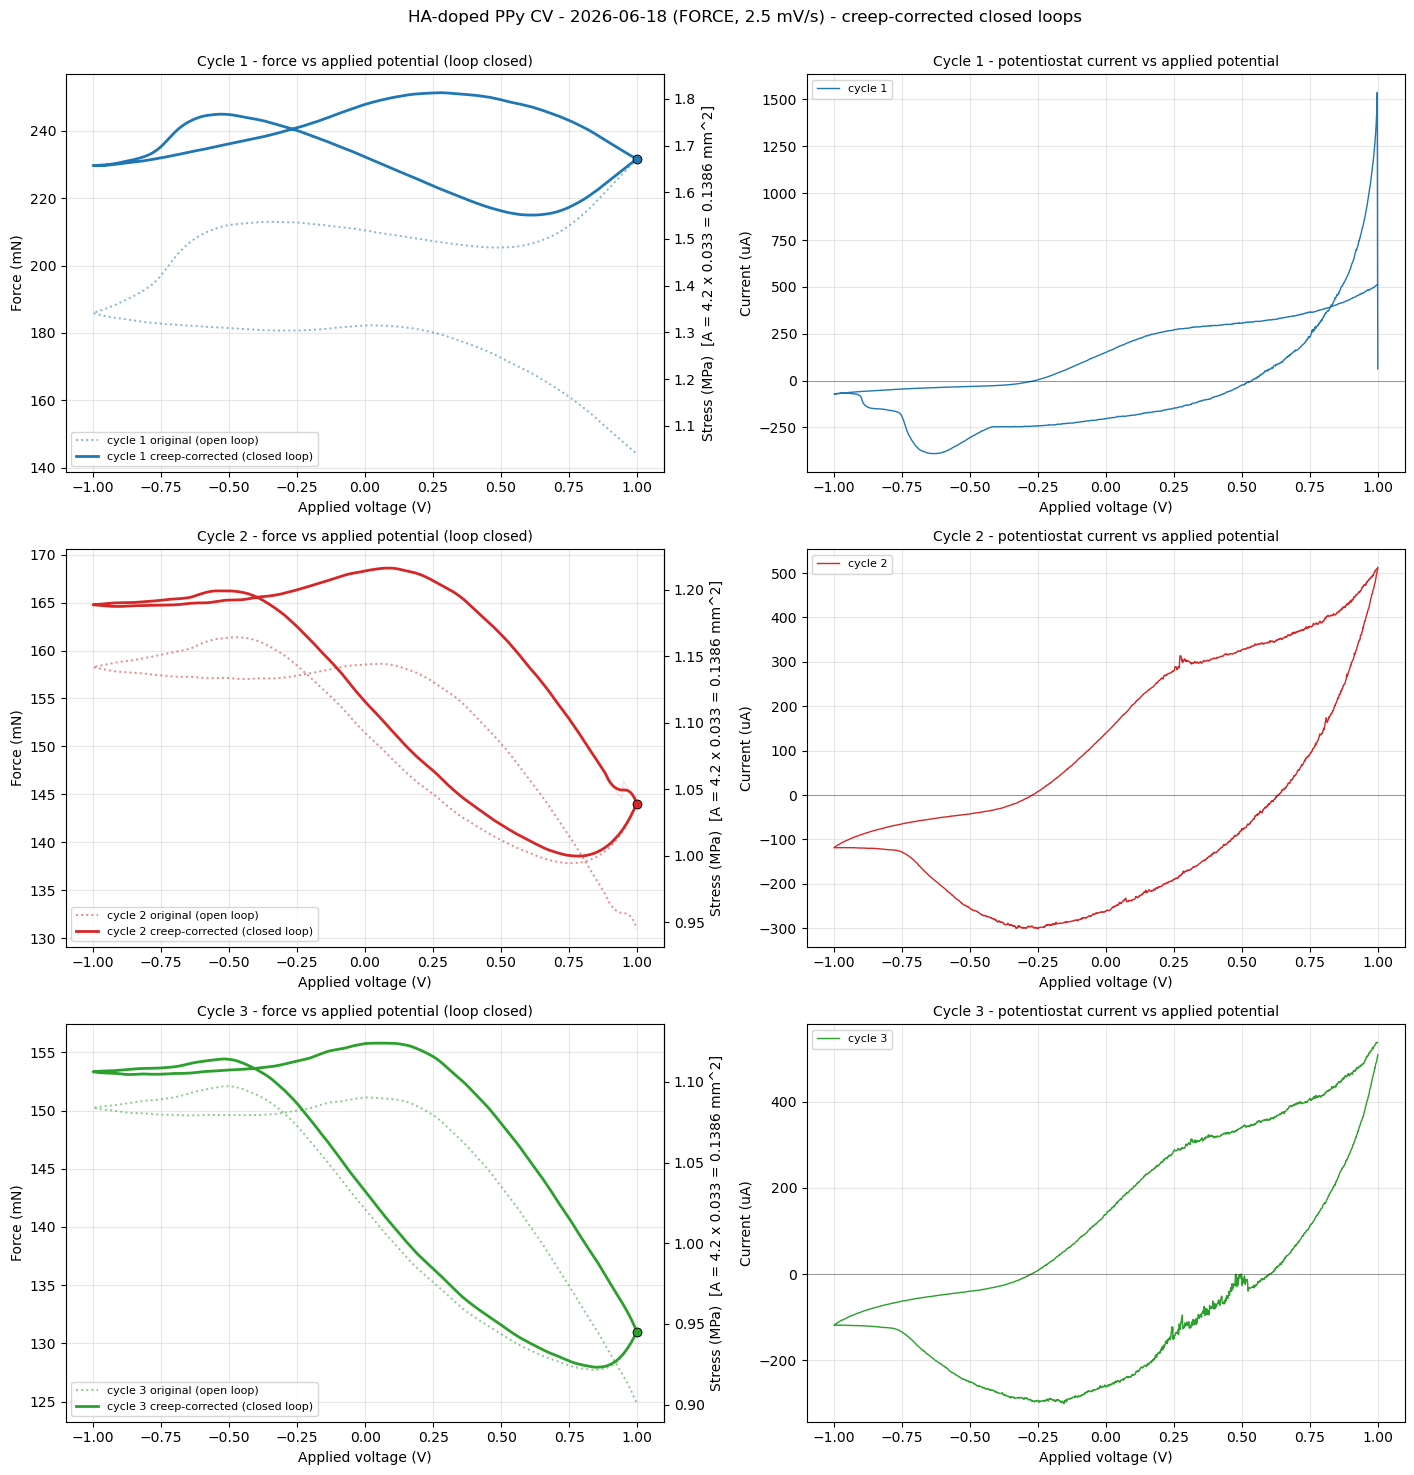

In [2]:
# Plot: rows = cycles, columns = (force vs applied voltage, potentiostat current vs voltage).
# Each cycle sweeps +1 V -> -1 V -> +1 V, so it returns to its start. We remove a per-cycle
# linear-in-time creep so each force loop CLOSES (start-+1 V == end-+1 V), and draw the
# original (open) loop as a faded dotted line behind the corrected (closed) solid loop.

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Sample geometry / calibration (FORCE, HA-doped film) ---
FORCE_GAIN_MN_PER_V = 56.7              # 1x gain
WIDTH_MM = 4.2
THICKNESS_MM = 0.033
LENGTH_MM = 2.9                         # actuation/force direction (not part of cross-section)
AREA_MM2 = WIDTH_MM * THICKNESS_MM      # 0.1386 mm^2 (cross-section perpendicular to force)
def mN_to_MPa(f): return f / AREA_MM2 / 1000.0     # 1 mN/mm^2 = 1 kPa = 1e-3 MPa
def MPa_to_mN(s): return s * AREA_MM2 * 1000.0

PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.20


def savgol_per_cycle(df, value_col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        w = min(window, n)
        if w % 2 == 0:
            w -= 1
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out


def close_loop_per_cycle(df, value_col, smooth_col):
    """Subtract a per-cycle linear-in-time drift so each cycle's last smoothed sample
    equals its first -- i.e. force(end-+1 V) == force(start-+1 V), closing the loop."""
    out = df[value_col].astype(float).copy()
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        t = sub['t_exp'].values
        y = sub[smooth_col].values
        if len(sub) < 2 or t[-1] == t[0]:
            continue
        slope = (y[-1] - y[0]) / (t[-1] - t[0])
        out.loc[sub.index] = df.loc[sub.index, value_col].values - slope * (t - t[0])
    return out


# Force in mN, smoothed, and the closed-loop (creep-corrected) version.
scope_clean['force_mN']      = scope_clean[SCOPE_CHANNEL] * FORCE_GAIN_MN_PER_V
scope_clean['smooth']        = savgol_per_cycle(scope_clean, 'force_mN', SMOOTH_WINDOW, SAVGOL_POLY)
scope_clean['force_closed']  = close_loop_per_cycle(scope_clean, 'force_mN', 'smooth')
scope_clean['smooth_closed'] = savgol_per_cycle(scope_clean, 'force_closed', SMOOTH_WINDOW, SAVGOL_POLY)

fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    # --- left: force vs applied voltage, closed loop (solid) over original (dotted) ---
    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.4, ls=':', alpha=0.55,
            label=f'cycle {c+1} original (open loop)')
    ax.plot(sub['v_applied'], sub['force_closed'], color=color, lw=0.6, alpha=RAW_ALPHA)
    ax.plot(sub['v_applied'], sub['smooth_closed'], color=color, lw=2.0,
            label=f'cycle {c+1} creep-corrected (closed loop)')
    ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
               [sub['smooth_closed'].values[0], sub['smooth_closed'].values[-1]],
               color=color, zorder=5, s=40, ec='k', lw=0.5)
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel('Force (mN)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_s = ax.secondary_yaxis('right', functions=(mN_to_MPa, MPa_to_mN))
    ax_s.set_ylabel(f'Stress (MPa)  [A = {WIDTH_MM} x {THICKNESS_MM} = {AREA_MM2:.4f} mm^2]')
    ax.set_title(f'Cycle {c+1} - force vs applied potential (loop closed)', fontsize=10)

    # --- right: potentiostat current ---
    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle('HA-doped PPy CV - 2026-06-18 (FORCE, 2.5 mV/s) - creep-corrected closed loops',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()

Per-cycle loop-closure gap (mN), end - start of smoothed force:
  cycle 1: before =  -87.50 mN   ->   after =   +0.00 mN
  cycle 2: before =  -13.01 mN   ->   after =   -0.00 mN
  cycle 3: before =   -6.18 mN   ->   after =   -0.00 mN

Per-cycle force / stress swing (creep-corrected closed loop):
  cycle 1: delta force =  36.32 mN   ->   delta stress =  262.05 kPa (0.2620 MPa)
  cycle 2: delta force =  30.04 mN   ->   delta stress =  216.77 kPa (0.2168 MPa)
  cycle 3: delta force =  27.85 mN   ->   delta stress =  200.94 kPa (0.2009 MPa)


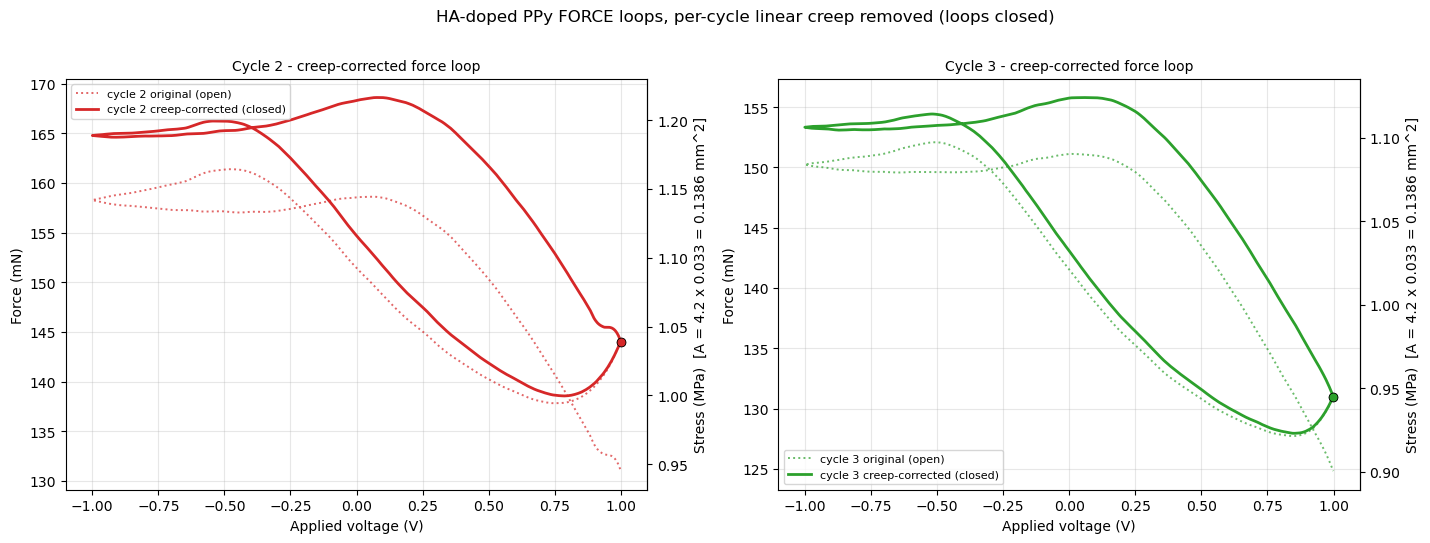

In [3]:
# Delta-stress summary + focused closed force loops.
# Delta-stress = peak-to-peak swing of the creep-corrected loop, converted to stress via area.
print('Per-cycle loop-closure gap (mN), end - start of smoothed force:')
for c in range(n_scans):
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    g0 = sub['smooth'].values[-1]        - sub['smooth'].values[0]
    g1 = sub['smooth_closed'].values[-1] - sub['smooth_closed'].values[0]
    print(f'  cycle {c+1}: before = {g0:+7.2f} mN   ->   after = {g1:+7.2f} mN')

print('\nPer-cycle force / stress swing (creep-corrected closed loop):')
for c in range(n_scans):
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    y = sub['smooth_closed'].values
    d_force = y.max() - y.min()                 # peak-to-peak force swing (mN)
    d_stress = mN_to_MPa(d_force) * 1000.0      # -> kPa
    print(f'  cycle {c+1}: delta force = {d_force:6.2f} mN   ->   delta stress = {d_stress:7.2f} kPa '
          f'({d_stress/1000:.4f} MPa)')

SHOW_CYCLES = [1, 2]   # 0-indexed -> cycles 2 and 3 (stabilized)
fig2, axes2 = plt.subplots(1, len(SHOW_CYCLES), figsize=(7.5*len(SHOW_CYCLES), 5.5), squeeze=False)
for j, c in enumerate(SHOW_CYCLES):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    ax = axes2[0, j]
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.4, ls=':', alpha=0.7,
            label=f'cycle {c+1} original (open)')
    ax.plot(sub['v_applied'], sub['smooth_closed'], color=color, lw=2.0,
            label=f'cycle {c+1} creep-corrected (closed)')
    ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
               [sub['smooth_closed'].values[0], sub['smooth_closed'].values[-1]],
               color=color, zorder=5, s=40, ec='k', lw=0.5)
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel('Force (mN)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_s = ax.secondary_yaxis('right', functions=(mN_to_MPa, MPa_to_mN))
    ax_s.set_ylabel(f'Stress (MPa)  [A = {WIDTH_MM} x {THICKNESS_MM} = {AREA_MM2:.4f} mm^2]')
    ax.set_title(f'Cycle {c+1} - creep-corrected force loop', fontsize=10)

fig2.suptitle('HA-doped PPy FORCE loops, per-cycle linear creep removed (loops closed)', fontsize=12)
fig2.tight_layout(rect=[0, 0, 0.96, 0.97])
plt.show()

## Separate figure: HA-doped voltammogram overlaid on distilled-pyrrole CV

Overlay the potentiostat CV current-vs-voltage curves for the **HA-doped** film and the
**distilled-pyrrole** film (both -25 C synthesis, 2.5 mV/s). Only the **stabilized cycles
(2 and 3)** are shown; the first-pass nucleation cycle is omitted.

- HA-doped: `potentiostat/06.18.26-HA-doped-ppy-FORCE-2.5mvperSec.csv`
- Distilled: `../cold_pyrrole_in_tissue_experiments_5.22.26/Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv`

Distilled-pyrrole potentiostat: 3 scans, 4034 samples/scan


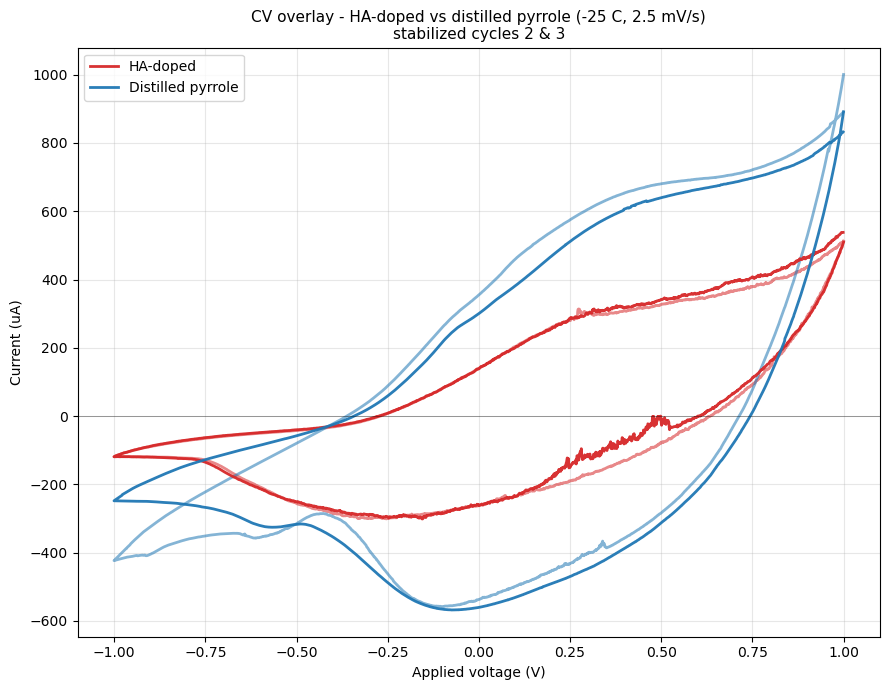

In [4]:
# Load distilled-pyrrole potentiostat CV and overlay both voltammograms (stabilized cycles 2 & 3 only).

def load_poten_cv(path):
    with open(path, 'rb') as f:
        text = f.read().decode('utf-16').replace('\ufeff', '')
    rows = list(csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))))
    rows = [r for r in rows if r and r[0]]
    nsc = len(rows[0]) // 2
    cols = []
    for s in range(nsc):
        cols += [f'v{s+1}', f'i{s+1}_uA']
    df = pd.DataFrame([[float(x) for x in r[:2*nsc]] for r in rows], columns=cols)
    return df, nsc

DIST_POTEN_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv'
dist_poten, dist_nscans = load_poten_cv(DIST_POTEN_CSV)
print(f'Distilled-pyrrole potentiostat: {dist_nscans} scans, {len(dist_poten)} samples/scan')

fig3, ax = plt.subplots(figsize=(9, 7))
HA_COLOR, DIST_COLOR = '#d62728', '#1f77b4'

# Stabilized cycles 2 & 3 only (cycle index 1 and 2). Cycle 3 full opacity, cycle 2 lighter.
for c in (1, 2):
    if c < n_scans:
        ax.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=HA_COLOR,
                lw=2.0, alpha=0.95 if c == 2 else 0.55,
                label='HA-doped' if c == 2 else None)
    if c < dist_nscans:
        ax.plot(dist_poten[f'v{c+1}'], dist_poten[f'i{c+1}_uA'], color=DIST_COLOR,
                lw=2.0, alpha=0.95 if c == 2 else 0.55,
                label='Distilled pyrrole' if c == 2 else None)

ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('Applied voltage (V)')
ax.set_ylabel('Current (uA)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_title('CV overlay - HA-doped vs distilled pyrrole (-25 C, 2.5 mV/s)\nstabilized cycles 2 & 3',
             fontsize=11)
fig3.tight_layout()
plt.show()

## Separate figure: HA-doped vs distilled-pyrrole STRESS cycles

Same alignment + creep-correction pipeline applied to the **distilled-pyrrole** scope force
log, then each loop is converted to **stress** using that film's own cross-section and the two
creep-corrected stress loops are overlaid. Both runs use the same force sensor (56.7 mN/V, 1x
gain); stress = force / (width x thickness).

- HA-doped:  A = 4.2 x 0.033 = **0.1386 mm^2**
- Distilled: A = 3.0 x 0.028 = **0.0840 mm^2**  (dimensions from `cv_20260602_FORCE_analysis.ipynb`)

Each loop is plotted as **change in stress relative to its +1 V start** (delta stress) so the
actuation swings line up at the origin; stabilized cycles 2 & 3 are shown.

- Distilled scope: `../cold_pyrrole_in_tissue_experiments_5.22.26/scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv`

Distilled force: 3 cycles, 9675 clean scope rows
Areas (mm^2): HA = 0.1386, distilled = 0.0840


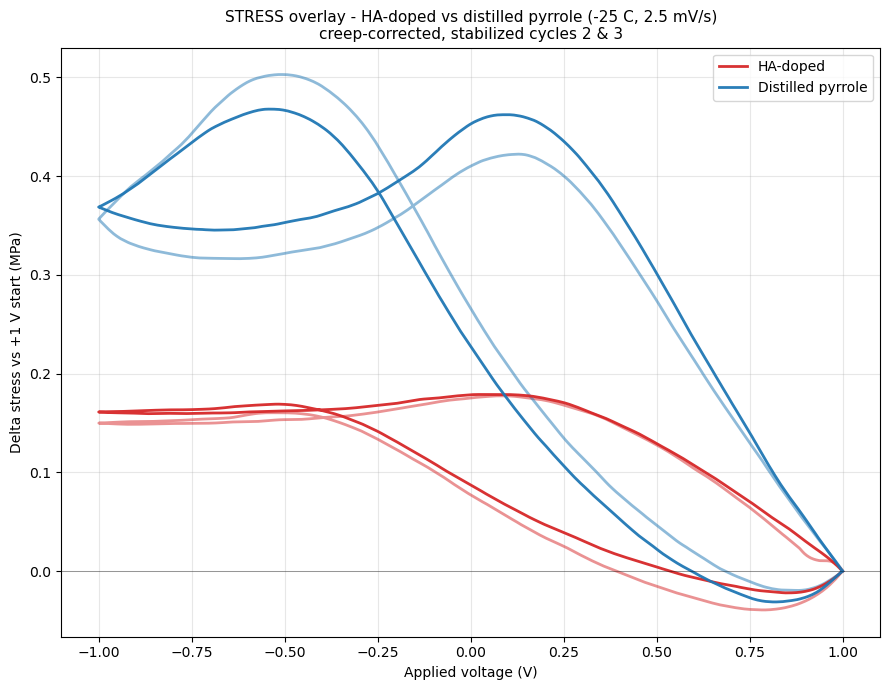


Peak-to-peak STRESS swing (creep-corrected closed loop):
  HA-doped   cycle 1:  36.32 mN  ->    262.0 kPa  (0.2620 MPa)
  HA-doped   cycle 2:  30.04 mN  ->    216.8 kPa  (0.2168 MPa)
  HA-doped   cycle 3:  27.85 mN  ->    200.9 kPa  (0.2009 MPa)
  Distilled  cycle 1:  71.14 mN  ->    846.9 kPa  (0.8469 MPa)
  Distilled  cycle 2:  43.87 mN  ->    522.3 kPa  (0.5223 MPa)
  Distilled  cycle 3:  41.91 mN  ->    498.9 kPa  (0.4989 MPa)


In [5]:
# Reusable pipeline: scope force log + potentiostat -> creep-corrected per-cycle force.
def process_force(scope_csv, poten_csv, scan_rate=0.0025, channel='ch2_MEAN_V',
                  gain=56.7, window=41, k=5.0, smooth_window=101, poly=3):
    pot, nsc = load_poten_cv(poten_csv)
    v1 = pot['v1'].values
    turn = int(np.argmin(v1))
    dt = abs(v1[0] - v1[turn]) / turn / scan_rate
    per_scan = len(pot) * dt
    total = nsc * per_scan
    t_scan = np.arange(len(pot)) * dt
    t_full = np.concatenate([t_scan + s*per_scan for s in range(nsc)])
    v_full = np.concatenate([pot[f'v{s+1}'].values for s in range(nsc)])
    sc = pd.read_csv(scope_csv)
    sc['t_exp'] = sc['elapsed_s']
    sc = sc[(sc['t_exp'] >= 0) & (sc['t_exp'] <= total)].copy()
    m = mark_outliers(sc[channel].values, window=window, k=k)
    sc = sc.loc[~m].copy()
    sc['v_applied'] = np.interp(sc['t_exp'].values, t_full, v_full)
    sc['cycle'] = np.clip((sc['t_exp'].values // per_scan).astype(int), 0, nsc-1)
    sc['force_mN'] = sc[channel] * gain
    sc['smooth'] = savgol_per_cycle(sc, 'force_mN', smooth_window, poly)
    sc['force_closed'] = close_loop_per_cycle(sc, 'force_mN', 'smooth')
    sc['smooth_closed'] = savgol_per_cycle(sc, 'force_closed', smooth_window, poly)
    return sc, nsc

# Each film's cross-section (mm^2). HA values come from the geometry cell above.
HA_AREA_MM2   = AREA_MM2                       # 4.2 x 0.033 = 0.1386
DIST_AREA_MM2 = 3.0 * 0.028                    # 0.0840  (from cv_20260602_FORCE_analysis.ipynb)
def force_to_MPa(f, area): return f / area / 1000.0     # mN / mm^2 = kPa -> /1000 = MPa

DIST_SCOPE_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv'
dist_force, dist_force_nscans = process_force(DIST_SCOPE_CSV, DIST_POTEN_CSV)
print(f'Distilled force: {dist_force_nscans} cycles, {len(dist_force)} clean scope rows')
print(f'Areas (mm^2): HA = {HA_AREA_MM2:.4f}, distilled = {DIST_AREA_MM2:.4f}')

def rel_stress(sub, area):
    """Change in creep-corrected stress (MPa) relative to the cycle's +1 V start."""
    s = force_to_MPa(sub['smooth_closed'].values, area)
    return s - s[0]

fig4, ax = plt.subplots(figsize=(9, 7))
for c in (1, 2):                 # stabilized cycles 2 & 3
    op = 0.95 if c == 2 else 0.5
    sub_ha = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    ax.plot(sub_ha['v_applied'], rel_stress(sub_ha, HA_AREA_MM2), color=HA_COLOR, lw=2.0, alpha=op,
            label='HA-doped' if c == 2 else None)
    sub_d = dist_force[dist_force['cycle'] == c].sort_values('t_exp')
    ax.plot(sub_d['v_applied'], rel_stress(sub_d, DIST_AREA_MM2), color=DIST_COLOR, lw=2.0, alpha=op,
            label='Distilled pyrrole' if c == 2 else None)

ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('Applied voltage (V)')
ax.set_ylabel('Delta stress vs +1 V start (MPa)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_title('STRESS overlay - HA-doped vs distilled pyrrole (-25 C, 2.5 mV/s)\n'
             'creep-corrected, stabilized cycles 2 & 3', fontsize=11)
fig4.tight_layout()
plt.show()

# Peak-to-peak stress swing per cycle, both films.
print('\nPeak-to-peak STRESS swing (creep-corrected closed loop):')
for label, df, nsc, area in [('HA-doped', scope_clean, n_scans, HA_AREA_MM2),
                             ('Distilled', dist_force, dist_force_nscans, DIST_AREA_MM2)]:
    for c in range(nsc):
        f = df[df['cycle'] == c].sort_values('t_exp')['smooth_closed'].values
        d_mpa = force_to_MPa(f.max() - f.min(), area)
        print(f'  {label:10s} cycle {c+1}: {f.max()-f.min():6.2f} mN  ->  {d_mpa*1000:7.1f} kPa  ({d_mpa:.4f} MPa)')